<h1 id="tocheading">Estudio de Interconección SAEB</h1>
<div id="toc"></div>

> Para determinar la viabilidad técnica de la integración de tecnologías de bajas emisiones de carbono, como ciertos Recursos Energéticos Distribuidos o Dispersos (DER), a saber: Vehículos Eléctricos, Paneles Fotovoltaicos (a gran o pequeña escala) y Sistemas de Almacenamiento, es menester llevar a cabo un estudio de *interconexión* para la identificación y evaluación de vulnerabilidades en la red desbalanceada y, con ello, si amerita, la reesquematización de la misma, ya sea a media o baja tensión.

A pesar de que la *Respuesta a la Demanda* pueda entenderse conceptualmente también como otro DER (agregado o no), este estudio no la contempla; más bien, busca levantar escenarios que sometan a estrés al sistema, avanzando en una penetración paulatina. Para ello, se utiliza un algoritmo que computa la capacidad de alojabilidad [1], basado en modelo, con énfasis en diferencias de tensión y corrientes de cortocircuito. Se dirá que el *caso base* es aquel cuya penetración es nula, es decir, el estado actual de la red incluyendo su generación distribuida inicial. En tanto, el *caso DER* incorpora, en la cola del circuito de media tensión —donde nacen otros dos circuitos—, un Sistema de Almacenamiento de Energía con Batería (SAEB).


## Contenido
* [Topología y Conectividad de la red de distribución](#first-section)
* [Calibración del modelo](#second-section)
* [Intergración del DER (SAEB)](#der-innerconnection)
* [Análisis de pérdidas técnicas](#third-section)
* [Perfiles de tensión](#voltage-profile)
    - [Líneas críticas](#critical-branches)
    - [Aumento de tensión](#delta-voltage)
* [Estudio de fallas](#fourth-section)
    - [Fallas en media tensión](#mv-faults)
    - [Fallas en baja tensión](#lv-faults)
* [Curvas de tiempo para coordinación de protecciones](#protection-curves)
* [Conclusiones](#end)
* [Referencias y Documentación](#references)

---

## Topología y Conectividad de la red de distribución <a class="anchor" id="first-section"></a>

En el marco eléctrico, la red de distribución en cuestión es un circuito desbalanceado no mallado, modelado en OpenDSS [2] con zonas trifásicas y monofásicas. Aunque cuenta con elementos de protección e.g Interruptores y fusibles no cuenta con elementos de regulación de tensión estrictos e.g. Autotransformadores, Bancos de Capacitores, Condensadores síncronos. El circuito discurre desde la subestación modelada como un transformador trifásico de tres devanados pasa por cargas monofásicas de baja tensión y desemboca en aquella barra (patio de interruptores) en la que convergen otros dos circuitos pero que son representados como dos cargas concentradas, trifásicas de media tensión cada una, de potencia activa y reactiva constante.

En el marco topológico el circuito es una red *radial*, es decir, un árbol cuya raíz es la fuente y cuyas hojas son las cargas. Se sabe por teoría de grafos que un árbol por definición no tiene ciclos, anillos o lazos por tanto la diferencia entre la cardinalidad de los vertices (barras) y aristas (ramas) es **uno** dado que una arista es la unión de dos vértices. Tras contar barras y ramas se obtiene 2304 y 2303 respectivamente, luego el criterio se satisface y la red es radial como se desea.

*Nota*: Las ramas pueden ser transformadores, líneas, etc. Es decir cualquier elemento que vaya de una barra a otra independientemente de los *nodos* de la barra a los que tal o cual terminal del elemento se conecta. De tal manera que los bancos de transformadores equivalen a una sóla rama así como cualquier transformador monofásico de tres devandos. Se asumió que la barra terciaria de la subestación no está energizada.

Se dice que un grafo está conectado si el número de componentes es único, o sea, si para cualesquiera vértices existe una ruta no trivial (tren de aristas o vértices) que los une. Luego un algoritmo de recorrido del grafo, debería recorrer todos los vértices a partir de un único vértice inicial arbitrario. Cuando de una red eléctrica se trata es más natural recorrerla por profundidad que por anchura, así se implementa un *Depth First Search* (DFS) para evualuar la conectividad. Como se comtempla que el número de barras recorridas coinciden con el número de vértices de modo que se cumple el criterio y se demuestra que la red está conectada.

In [1]:
import host as ht

gis_ckt = ht.GISCircuit(gis_path="./GIS-2203/*.shp")
ckt_map = gis_ckt.explore_ckt()
# ckt_map.save("ckt.html")

EmptyGeoDataFrame: No values in LoadsMV.


In [2]:
# Head location
print(gis_ckt.layers['Substation'][0])
# Tail location
gdf = gis_ckt.layers['BusesMV'][0]
print(gdf[gdf['DSSNAME'] == "busmvnsp_1303"])

  DSSNAME         BUS_MV  kV_HV  kV_MV  kV_LV      kVA   xhl    xht    xlt  \
0    hvmv  busmvnsp_2203  230.0   34.5   13.8  30000.0  9.98  18.84  3.166   

   numtaps  tap                   geometry  
0       33    1  POINT (-84.17304 9.99766)  
           DSSNAME   Dist_m  V_Base  Vpmax   Vmax   Vmin  Vdelta Desconec  \
244  busmvnsp_1303  2472.71   19.92  0.999  0.999  0.999     0.0       NO   

                       geometry  
244  POINT (-84.16937 10.01402)  


In [3]:
bolt_icon = ht.folium.Icon(icon='bolt', prefix='fa', color='red')
battery_icon = ht.folium.Icon(icon='battery-full', prefix='fa', color='green')

# Switched coord.
head_loc = [9.998, -84.173]
tail_loc = [10.01402, -84.16937]
ht.folium.Marker(
    location=head_loc,
    icon=bolt_icon,
    popup="Subestación"
).add_to(ckt_map)

ht.folium.Marker(
    location=tail_loc,
    icon=battery_icon,
    popup="SAEB",
).add_to(ckt_map)

ckt_map

In [4]:
base_ckt = ht.BaseCicuit(
    ckt_path="./2203/2203_Master.dss"
)
graph = ht.CktGraph(base_ckt)

print("|Buses|: ", len(graph.vertices))
print("|Branches|: ", len(graph.edges))


|Buses|:  2304
|Branches|:  2303


In [5]:
tree_branches = []
for branch in graph.dfs_edges():
    tree_branches.append(branch)

n_vertices = len(tree_branches) + 1
print(n_vertices)

2304


In [6]:
buses = []
with open("./2203/2203_CoordinatesBusesLV.csv", "r") as file:
    for line in file:
        if line:
            bus = line.split(",")[0].lower()
            buses.append(bus)

with open("./2203/2203_CoordinatesBusesMV.csv", "r") as file:
    for line in file:
        if line:
            bus = line.split(",")[0].lower()
            buses.append(bus)

print(len(buses))

for bus in graph.vertices:
    if bus not in buses:
        print(bus)

2299
sourcebus
buslvnoe51b9e81-7791-4bb7-bf7e-49b01eb7ccf5cplvpcn
buslvno95968b65-b0bf-442e-b14f-871b85cd66b6cplvpcn
buslvno922a8285-f135-4266-abbb-5f29fe995080cplvpcn
buslvno7149c81b-d061-4f04-a1c5-d969ae1e124acplvpcn


## Calibración del modelo <a class="anchor" id="second-section"></a>

La demanda medida durante un período típico de 24 horas se compara con la demanda simulada (virtual) del caso base. Como muestra la figura [ ], el estrecho comportamiento entre ambas respalda la calibración del modelo del caso base utilizado en el estudio de interconexión. De hecho, se asemejan tanto que resulta inusual, y esto se debe a dos cargas de media tensión relativamente dominantes que, en realidad, condensan dos circuitos mayores.

Salta a la vista que la demanda del caso base virtual está algo sobredimensionada y, aunque se pudieron haber ajustado sus curvas de demanda para lograr una mayor precisión, conviene, sin embargo, en estos estudios, simular situaciones desfavorables o más severas que las normales, con el fin de obtener mayores márgenes de seguridad y dimensionamientos más robustos.

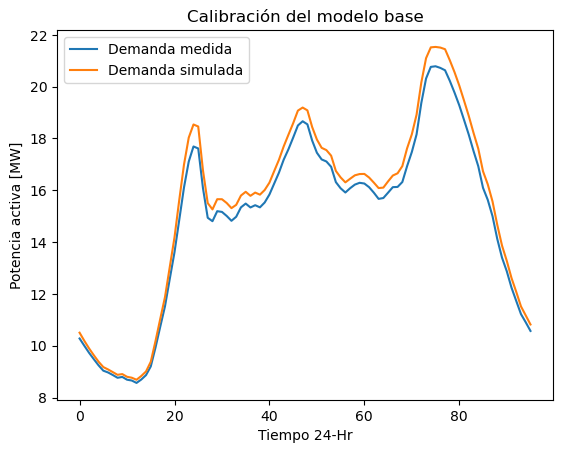

In [7]:
import pandas as pd

df = pd.read_csv("./profiles.csv")
measurements_df = df[df["ID"] == 2203][:-1]['Potencia_activa'].values

base_losses = base_ckt.calculate_losses()

ht.plt.plot(
    measurements_df * 1e-3,
    label="Demanda medida"
)
ht.plt.plot(
    base_ckt.feeders_power[:, 0] * 1e-3,
    label="Demanda simulada"
)
ht.plt.title("Calibración del modelo base")
ht.plt.xlabel("Tiempo 24-Hr")
ht.plt.ylabel("Potencia activa [MW]")

ht.plt.plot()
ht.plt.legend()
# ht.plt.savefig("fig1.png", dpi=350)
ht.plt.show()


Efectivamente, la potencia pico representativa de referencia es de 20.80 [MW], mientras que la virtualmente obtenida es de 21.53 [MW]. Para los análisis posteriores se utilizará esta última, la cual sostiene un consumo diario acumulado $S_{net}$ de (1480.92, 129.12) [MW, MVAr].

In [8]:
print(
    "Actual peak [MW]",
    max(measurements_df*1e-3)
)
print(
    "Base peak [MW]",
    max(base_ckt.feeders_power[:, 0]*1e-3)
)

Actual peak [MW] 20.786240000000003
Base peak [MW] 21.53283984375


In [9]:
active_p = sum(base_ckt.feeders_power[:, 0]*1e-3)
reactive_q = sum(base_ckt.feeders_power[:, 1]*1e-3)
complex_power = active_p + 1j*reactive_q
print("Apparent base power [MW, MVAr]: ", complex_power)

Apparent base power [MW, MVAr]:  (1480.9194433593752+129.11827197265626j)


## Intergración *DER* al sistema <a class="anchor" id="der-innerconnection"></a>

Un SAEB es una clase de *DER* pero que en lontananza parece un generador, de hecho en OpenDSS es una extensión del objecto *Generador* pero con inversor, la dinámica de éste componente luego presentará algunos retos en condiciones de falla como se verá más adelante.

También merece la pena desentrañar los diferentes tipos de pérdidas involucadas en el modelo, a saber, la eficiencia del inversor ($\eta_{inv}$) que no se define explícitamente como un único parámetro en cambio, se incluye en las propiedades `%EffCharge` y `%EffDischarge`, que representan la eficiencia de carga y descarga, además de incluir las pérdidas internas e.g. térmicas o de cableado. La que sí se pueden definir por aparte son las pérdida de reposo, `%IdlingkW` incluso sin carga ni descarga, análogas a la corriente de magnetización de un trasformador.



- Modelo de potencia de carga efectiva.

$$
\boxed{

    P_{eff}^{ch} = \left(P_{in}\eta_{inv} - P_{idl} \right) \cdot \eta_{ch}
}
$$

donde $P_{idl}$ es conocido, y corresponde al consumo constante por ocio (reposo).

- Modelo de potencia de descarga efectiva.

$$
P_{eff}^{dch} = P_{out} + P_{\text{losses, tot}}^{dch}
$$

donde $P_{\text{losses, tot}}^{dch}$ equivale a las pérdidas por *Inversor*, *Ocio* e *Internas*, en cuanto a la primera con eficiciencia de $\eta_{inv}$:

$$
P_{\text{loss, inv}}^{dch} = P_{\text{desired}}^{inv} - P_{out}
$$

Y en cuanto a las Internas con eficiencia de $\eta_{dch}$:

$$
P_{\text{losses, dch}} = P_{\text{desired}}^{dch} - \hat{P}_{out}
$$

donde $\hat{P}_{out}$ suple tanto $P_{\text{desired}}^{inv}$ como $P_{idl}$, sea

$$
\eta_{inv} = \frac{P_{out}}{P_{\text{desired}}^{inv}}
$$

entonces

$$
P_{\text{desired}}^{inv} = \frac{P_{out}}{\eta_{inv}}
$$

Luego

$$
P_{\text{loss, inv}}^{dch} = P_{out}\left(\frac{1}{\eta_{inv}} -1 \right)
$$

por otro lado 

$$
\eta_{dch} = \frac{\hat{P}_{out}}{P_{\text{desired}}^{dch}}
$$

o sea

$$
P_{\text{desired}}^{dch} = \frac{\hat{P}_{out}}{\eta_{dch}}
$$

reescribiendo pérdidas internas

$$
P_{\text{losses, dch}} = \frac{\hat{P}_{out}}{\eta_{dch}} - \hat{P}_{out}
$$

Factorizando

$$
P_{\text{losses, dch}} = \hat{P}_{out} \left (\frac{1}{\eta_{dch}} - 1 \right)
$$

o bien

$$
P_{\text{losses, dch}} = \left ( P_{\text{desired}}^{inv} + P_{idl} \right) \left (\frac{1}{\eta_{dch}} - 1 \right)
$$

Finalmente las pérdidas internas de descarga

$$
P_{\text{losses, dch}} = \left ( \frac{P_{out}}{\eta_{inv}} + P_{idl} \right) \left (\frac{1}{\eta_{dch}} - 1 \right)
$$

Así la potencia de descarga efectiva

$$
P_{eff}^{dch} = P_{out} + P_{\text{losses, dch}} + P_{idl} + P_{\text{loss, inv}}^{dch}
$$

Evaluando y simplificando:

$$
\boxed{
    P_{eff}^{dch} = \frac{P_{out}}{\eta_{inv}\eta_{dch}} + \frac{P_{idl}}{\eta_{dch}}
}
$$

El primer término representa la energía que realmente debe extraerse del sistema (desde la batería) para lograr $P_{out}$ útil, considerando las dos eficiencias en cascada mientras que el otro representa el efecto del consumo por ocio $P_{idl}$, también penalizado por la eficiencia de descarga.


Si bien el estudio en cuestión, por su naturaleza, se enfoca en los instantes críticos para la curva de carga característica dada del sistema, se genera también otro escenario ilustrativo pero que ayuda a poner en perspectiva el escenario crítico, llámese escenario económico y cuyos parámetros se tabulan en [].


| Parámetro                             | Despacho Crítico               | Despacho Económico      |
| ------------------------------------- | ------------------------------ | ----------------------- |
| **Nombre**                            | tec_battery                    |  eco_battery            |
| **Barra de conexion**                 | BUSMVnSP_1303                  |  BUSMVnSP_1303          |
| **Fases**                             | 3                              |  3                      |
| **Tensión Nominal**                   | 34.5 [kV]                      |  34.5 [kV]              |
| **Potencia Asignada**                 | 5 [MW]                         |  5 [MW] (0.5C en carga) |
| **Capacidad de Energía**              | 10 [MWh]                       |  10 [MWh]               |
| **Modelo**                            | $P_\text{out}$ constante       |  $P_{\text{out}}$ constante  |
| **Factor de potencia** (como *generador*)               | +1.0 en atraso                 |  +1.0 en atraso         |
| **SoC Inicial**                       | 10% (1.0 [MWh])                |  50% (5.0 [MWh])        |
| **SoC de Reserva**                    | 10% (1.0 [MWh])                |  10% (1.0 [MWh])        |
| **Modo de Despacho**                  | `follow`                       |  `follow`               |
| **Eficiencia (ciclo completo)**       | ≈ 90.25%                       |  ≈ 90.25%               |
| **Carga efectiva**                    | 4.753 [MW]                     |  4.753 [MW] (2.3765 [MW])    |
| **Descarga efectiva**                 | 5.258 [MW]                     |  5.258 [MW]             |
| **Consumo en ocio (% de $P_{\text{out}}$)** | 1% (0.05 [MW])           |  1% (0.05 [MW])         |


La barra es de media tensión a la cola del circuito, en el punto justo en que nacen otros dos circuitos. El modo de despacho *follow* se refiere a un "seguimiento de carga" cuya lógica de operación (carga y descarga) es impuesta por la curva de despacho diaria. Una eficiencia de ciclo completo se refiere a la ida y vuelta i.e. EfCarga (95%) y EfDescarga (95%), donde éstas eficiencias ya incluyen las del inversor, no obstante las de ocio se dejan en 1% de la capacidad energética asignada, entonces

$$
\eta_{ch}^{ef} \cdot \eta_{dch}^{ef} = \eta_{\text{round-trip}}
$$

En términos prácticos, si se asignase una potencia de 5[MW] y de 10[MWh] de capacidad energética al elemento de almacenamiento cuyo estado de carga inicial es del 10% de su capacidad energética nominal (1.0 [MWh]), con pérdidas del 1% de la potencia asignada por ocio (i.e. 0.05 [MW]) con eficiencias $\eta_{ch}$ y $\eta_{dch}$ del 97% y un $\eta_{inv}$ del 98% (tal que sea alrededor del 95% entre ambas) se tendría una potencia de carga efectiva del 4.753[MW] luego para que el elemento quede apenas cargado bastan 9[MWh] los cuales se consiguen con una hora y 55 minutos de carga. Sea la hora de carga a las 2:00am tal que coincida con el periodo nocturno.

Luego se calcula una descarga de potencia efectiva de 5.258 [MW] y casi diez horas y media después, a las 06:15pm, en el umbral del pico, el dispositivo se descarga, para entonces el estado de carga sería 9.283 [MWh] por culpa del letargo, de los cuales solamente 8.283 [MWh] son despachables (si se quiere un 10% de reserva), de modo que el elemento termina drenado en poco más de hora y media. Finalmente el SAEB pasará las próximas seis horas y 10 min en reposo (con fuga acumulada de 0.309 [MWh]), hasta las 2am del siguiente día en que el ciclo comience de nuevo, para entonces el reservorio estará a 0.691 [MWh] es decir, algo menos del estado de carga en que arrancó. Las tablas [] y [] resumen la estrategia dinámica de cada despacho.

### Despacho Crítico

| Etapa        | Hora inicio | Hora fin | Duración | Detalles                                 |
| ------------ | ----------- | -------- | -------- | ---------------------------------------- |
| **Carga**    | 02:00       | 03:55    | 1.915 h  | SoC sube de 1.0 a 10.0 MWh               |
| **Reposo 1** | 03:55       | 18:15    | 14.333 h | Fuga de 0.717 MWh → SoC: 9.283 MWh       |
| **Descarga** | 18:15       | 19:49    | 1.576 h  | SoC baja a 1.0 MWh (reserva del 10%)     |
| **Reposo 2** | 19:49       | 02:00\*  | 6.183 h  | Fuga de 0.309 MWh → SoC final: 0.691 MWh |


### Despacho Económico (a 0.5 C en carga)


| Etapa         | Hora inicio | Hora fin | Duración | Detalles                             |
| ------------- | ----------- | -------- | -------- | ------------------------------------ |
| **Carga**     | 02:00       | 04:06    | 2.104 h  | SoC sube de 5.0 a 10.0 MWh           |
| **Reposo 1**  | 04:06       | 11:30    | 7.40 h   | Fuga de 0.370 MWh → SoC: 9.630 MWh   |
| **Descarga**  | 11:30       | 13:08    | 1.641 h  | SoC baja a 1.0 MWh (reserva del 10%) |
| **Reposo 2**	| 13:08	      | 02:00\*	 | 13.859 h	| Fuga de 0.6929 MWh → SoC final: 0.307 MWh |

\* Día siguiente

Note que el llamado "Despacho económico" en tanto que comienza con 5 [MWh] y de ello se inyecta, en concepto de aporte energético, 4.693 [MWh] ésta cortesía del 46.93% de la capacidad de almacenamiento del reservorio es un aporte sustancial que viene a aliviar la carga efectiva sentida por la fuente luego —en cuanto a los cálculos de pérdidas globales se refieren— los derivados de éste escenarios son *falibles*. Por su parte el escenario crítico deja un excedente del 3% y se asumirá aceptable.


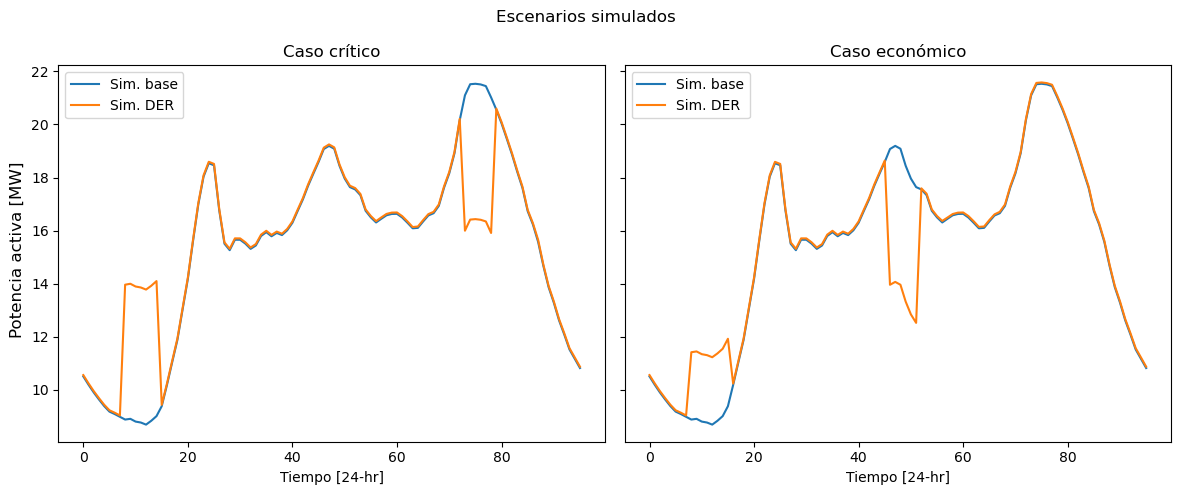

In [10]:
tecder_data = [
    {
        "storage_id": "tec_battery",
        "bus_id": "BUSMVnSP_1303",
        "phases": 3,
        "kV": 34.5,
        "kW": 5000.0,
        "kWh": 10000.0,
        "model": 1,
        "per_stored": 10.0,
        "per_reserve": 10.0,
        "dispatch_mode": "follow",
        "daily_id": "tec_dispatch",
        "per_efficiencies": (95.0, 95.0),
        "dispatch_schedule": ((2, 3.915), (18.25, 19.826))
    }
]

ecoder_data = [
    {
        "storage_id": "eco_battery",
        "bus_id": "BUSMVnSP_1303",
        "phases": 3,
        "kV": 34.5,
        "kW": 5000.0,
        "kWh": 10000.0,
        "model": 1,
        "per_stored": 50.0,
        "per_reserve": 10.0,
        "dispatch_mode": "follow",
        "daily_id": "eco_dispatch",
        "per_efficiencies": (95.0, 95.0),
        "dispatch_schedule": ((2, 4.104), (11.5, 13.14134557)),
        "charge_pace": 0.5
    }
]

# Crital case
tec_ckt = ht.DERCircuit(
    ckt_path="./2203/2203_Master.dss",
    bess_attrs=tecder_data
)

tec_der_losses = tec_ckt.get_monitor_data(   # [W, VAr]
    "tec_battery_monitor_9", reset=False
)
tec_losses = tec_ckt.calculate_losses()

# Economic case
eco_ckt = ht.DERCircuit(
    ckt_path="./2203/2203_Master.dss",
    bess_attrs=ecoder_data
)

eco_der_losses = eco_ckt.get_monitor_data(   # [W, VAr]
    "eco_battery_monitor_9", reset=False
)

eco_losses = eco_ckt.calculate_losses()


fig, axs = ht.plt.subplots(1, 2, sharey=True, figsize=(12, 5))
titles = ["Caso crítico", "Caso económico"]

for n, title in enumerate(titles):
    if n == 0:
        axs[n].plot(
            base_ckt.feeders_power[:, 0] * 1e-3,
            label="Sim. base"
        )
        axs[n].plot(
            tec_ckt.feeders_power[:, 0] * 1e-3,
            label="Sim. DER"
        )
    elif n == 1:
        axs[n].plot(
            base_ckt.feeders_power[:, 0] * 1e-3,
            label="Sim. base"
        )
        axs[n].plot(
            eco_ckt.feeders_power[:, 0] * 1e-3,
            label="Sim. DER"
        )

    axs[n].set_title(title)
    axs[n].legend()
    axs[n].set_xlabel("Tiempo [24-hr]")

fig.supylabel("Potencia activa [MW]")
fig.suptitle("Escenarios simulados")
fig.tight_layout()
# ht.plt.savefig("fig2.png", dpi=350)
ht.plt.show()


La figura superior [] deja ver un comportamiento esperado de acuerdo con la estrategia de despacho planteada. Y aunque por la cara de potencia activa se ven picos apisonados, por la otra cara, la potencia reactiva, también ha de reflejar beneficios en la tensión como ya se verá.

Un sensor conectado al SAEB reporta 9.15 [MW] de pérdidas reales acumuladas a lo largo del ciclo bajo el caso crítico, mientras que, en el caso económico, en el mismo periodo, se registran -5.90 [MW] (es decir, generación). Consecuentemente, otro medidor en la subestación contabiliza 1490.16 [MW] ($P_{gen}^{crit}$) y 1474.66 [MW] ($P_{gen}^{eco}$) de generación respectivamente. Esto tiene sentido en la medida en que la diferencia entre aumento o reducción de generación activa es atribuible al *DER*. Pero, hilando más fino, si el caso base —según se indicó en la calibración del modelo— corresponde a 1480.92 [MW] ($P_{gen}^{base}$), entonces:


$$
\Delta P_{gen}^{crit} = P_{gen}^{crit} -  P_{gen}^{base} = 9.24 \quad \text{[MW]}
$$

$$
\Delta P_{gen}^{eco} = P_{gen}^{eco} -  P_{gen}^{base} = -6.26 \quad \text{[MW]}
$$

Si bien aún no se puede hablar de pérdidas globales, se observa —al menos desde el efecto de cada parametrización del dispositivo sobre la red— que el caso económico se aleja más de las mediciones de su sensor (~0.36 [MW] en términos absolutos) que el crítico (~0.09 [MW]). En términos porcentuales relativos, se estima que en el caso económico este desajuste ronda el ~6% con base en $\Delta P_{gen}^{eco}$, mientras que en el caso crítico es apenas del ~1% con base en $\Delta P_{gen}^{crit}$. Ésta sutil diferencia será útil para explicar los perfiles de tensión más adelante.


In [11]:
# Nominal current
data = tec_ckt.get_monitor_data(
    "bess_monitor_tec_battery_vi", reset=False
)
data[75, 2::2]

array([1.9549246e+04, 1.9577900e+04, 1.9529990e+04, 0.0000000e+00,
       8.5254662e+01, 8.5129906e+01, 8.5338661e+01, 5.1376426e-01],
      dtype=float32)

De la figura anterior [ ], apenas se obtiene una *pintura eléctrica*, pero da pie a la contemplación de beneficios estratégicos en materia de pérdidas técnicas, que conlleva un uniformamiento manifiesto del consumo percibido desde la subestación, tanto en $P$ como en $Q$. En la sección de Tensión se ampliará sobre estos beneficios.

Tras alojar el SAEB, se observa —en términos netos— que este produce una leve cantidad de reactivo (35.47 [VAr]) a lo largo del día, consistente con el hecho de que fue dejado en atraso (bajo convención de generador), debido a la electrónica del inversor. Pese a que se configuró con un factor de potencia unitario, se percibe cierto efecto inductivo, aunque ciertamente despreciable.

Por otra parte, desde la subestación, destaca que hay menor producción de reactivo —un 1% menos—, y si la demanda se mantiene constante, esto se interpreta como un efecto favorable sobre $\delta$, tal que se requiere menos potencia real para suplir la misma carga, implicando menores pérdidas activas. Y de hecho, así es: se reportan 200 [kW] menos de pérdidas activas a lo largo del día (25.50 [MW] en el caso base, lo cual representa un 1.72%, frente a 25.30 [MW] con *DER*, correspondiente al 1.71%; ambos porcentajes relativos a los 1480.92 [MW] diarios generados), sin mencionar la reducción de pérdidas térmicas —con incidencia económica— que no han sido computadas.

Dicho lo anterior, se espera entonces ver, en la siguiente sección, una caída de tensión sutilmente más suave.

In [12]:
# BESS Device active losses
print("Monitor critical DER [MW]: ", sum(tec_der_losses[:, 2]) * 1e-6)
print("Monitor Eco DE [MW]: ", sum(eco_der_losses[:, 2]) * 1e-6)

Monitor critical DER [MW]:  9.149881839843749
Monitor Eco DE [MW]:  -5.9000152695312496


In [13]:
# BESS Device active losses
print("Monitor critical DER [MW]: ", sum(tec_der_losses[:, 2]) * 1e-6)
print("Monitor Eco DE [MW]: ", sum(eco_der_losses[:, 2]) * 1e-6)

Monitor critical DER [MW]:  9.149881839843749
Monitor Eco DE [MW]:  -5.9000152695312496


In [14]:
# Source generation
base_active = sum(base_ckt.feeders_power[:, 0] * 1e-3)
tec_active = sum(tec_ckt.feeders_power[:, 0] * 1e-3)
eco_active = sum(eco_ckt.feeders_power[:, 0] * 1e-3)

print("Base: [MW] by source", base_active)
print("Critical: [MW] by source", tec_active)
print("Economical: [MW] by source", eco_active)

Base: [MW] by source 1480.9194433593752
Critical: [MW] by source 1490.1578046875004
Economical: [MW] by source 1474.6631396484377


## Análisis de Pérdidas Técnicas <a class="anchor" id="third-section"></a>

Aunque no se suele pensar en pérdidas de potencia imaginaria $Q$ (VAr) en un sentido estricto, como sí se hace con la potencia real $P$ (W), ya que la primera está asociada al envío (transmisión) o almacenamiento de energía en forma de campo eléctrico (capacitivo) o magnético (inductivo), y salvo que existan condensadores síncronos, generadores subexcitados, etc. —que no es el caso—, dicha potencia no se puede *vaciar* ni disipar como para incurrir en pérdidas reactivas. Más bien, oscila en un ir y venir entre fuente y carga.

No obstante, sí puede modificar el ángulo de carga $\delta$ para una misma potencia aparente $S$, en detrimento o en virtud de la parte real, y por tanto, aumentar o reducir pérdidas activas. Así, mientras un residuo entre potencia activa generada y consumida equivale a pérdidas reales, no sucede lo mismo con un remanente de potencia reactiva. Para apreciar su efecto, se debe evaluar $P$.

Vale una nota respecto a la estrategia de despacho y a propósito de pérdidas no capturadas por el modelo eléctrico: las pérdidas reales durante horas críticas —es decir, momentos de alta demanda— son más costosas económicamente. Además, suelen coincidir con el periodo diurno, cuando la temperatura ambiente es más alta. Este aumento de temperatura, si bien no se contempla en el modelo, agrava físicamente (por efecto Joule) la conductividad y eficiencia de los materiales.

De modo que hay un *doble castigo* escondido. Por ello, es válido y sensato asumir que las pérdidas activas reales son superiores a las aquí reportadas, aunque no de manera significativa, ya que el modelo virtual es algo más severo que el caso verdadero, como se vio en la sección de calibración del modelo. Y en cuanto al impacto económico, el SAEB, al encontrarse más cercano al punto de consumo, debería reducir las pérdidas por caída de tensión durante circunstancias pico, al entrar en acción como respaldo.

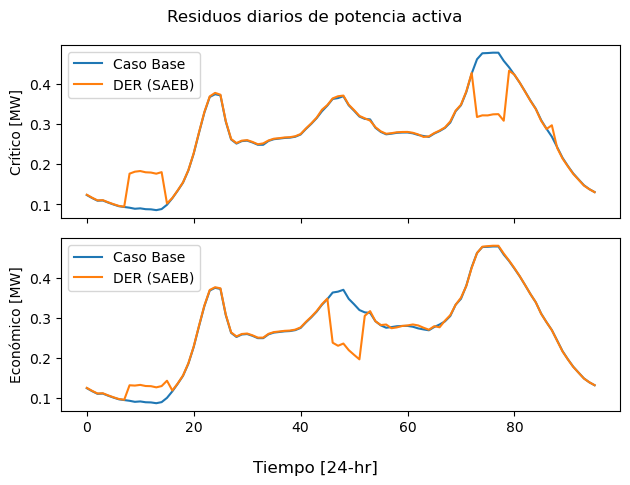

In [15]:
fig, axs = ht.plt.subplots(2, 1, sharex=True)
titles = ["Crítico [MW]", "Económico [MW]"]
for n, (title, der_losses) in enumerate(
    zip(titles, [tec_losses, eco_losses])
):
    axs[n].plot(
        base_losses[:, 0]*1e-3,
        label="Caso Base"
    )
    axs[n].plot(
        der_losses[:, 0]*1e-3,
        label="DER (SAEB)"
    )
    # axs[n].set_title(title)
    axs[n].legend()
    axs[n].set_ylabel(title)

fig.supxlabel("Tiempo [24-hr]")
fig.suptitle("Residuos diarios de potencia activa")
fig.tight_layout()

# ht.plt.savefig("fig3.png", dpi=350)
ht.plt.show()


De la figura anterior [ ], apenas se obtiene la *pintura eléctrica*, pero da pie a la contemplación de beneficios estratégicos en materia de pérdidas técnicas, que conlleva un uniformamiento manifiesto del consumo percibido desde la subestación, tanto en $P$ como en $Q$. En la sección de Tensión se ampliará sobre estos beneficios.

Tras alojar el SAEB, se observa —en términos netos— que se le entrega a la red una leve cantidad de reactivo en ambas estrategias de despacho: 110.2605 [VAr] en el caso crítico y 297.9242 [VAr] en el económico a lo largo del día. Esto es consistente con el hecho de que el dispositivo fue configurado en atraso (bajo convención de generador). Aunque se programó con un factor de potencia unitario, se percibe cierto efecto inductivo (debido a la electrónica del inversor) que se enfatiza en modo económico puesto que su participación en la generación predomina, como se discutió anteriormente.

Por otra parte, desde la subestación, bajo el esquema económico se inyecta un 1.41% menos de reactivo a la red, lo cual era previsible, dado el alivio de carga efectiva respecto al modelo base. Destaca, sin embargo, que en el caso crítico —donde la carga aumentó gracias a que la fuente intentó suplir las pérdidas del SAEB— también se observa una menor producción de reactivo (un 0.70% menos). Esto puede interpretarse como un efecto favorable sobre el ángulo $\delta$, de forma que se requiere menos potencia real para suplir la misma carga base, lo cual implica menores pérdidas activas.

Y en efecto así ocurre, en modo crítico se reportan 0.18 [MW] menos de pérdidas activas diarias (25.50 [MW] en el caso base, lo cual representa un 1.72% de $P_{gen}^{base}$, frente a 25.32 [MW] con *DER*, correspondiente al 1.70% sobre $P_{gen}^{crit}$). En el económico, por su parte, la reducción de pérdidas es naturalmente acentuadas a saber, 25.12 [MW] a lo largo del día, en tanto que hubo una reducción de la potencia entregada por la fuente, pero estos 0.38 [MW] menos con respecto al caso base no implican una eficiencia superior que el caso crítico, de hecho, es la misma 1.70% (con respecto a $P_{gen}^{eco}$).

Dicho lo anterior, se anticipa entonces ver, en la próxima sección, una caída de tensión más suave en los escenarios con *SAEB*.

In [16]:
print("Reactive net critical losses [VAr]:", sum(tec_der_losses[:, 3]))
print("Reactive net economical losses [VAr]:", sum(eco_der_losses[:, 3]))

Reactive net critical losses [VAr]: -297.924236659077
Reactive net economical losses [VAr]: -110.2605460457271


In [17]:
print("Base [MVAr]", sum(base_ckt.feeders_power[:, 1]*1e-3))
print("\nCritical DER [MVAr]", sum(tec_ckt.feeders_power[:, 1]*1e-3))
print("Economic DER [MVAr]", sum(eco_ckt.feeders_power[:, 1]*1e-3))

Base [MVAr] 129.11827197265626

Critical DER [MVAr] 128.21246908569339
Economic DER [MVAr] 127.29651223754884


In [18]:
net_active_base_losses = sum(base_losses[:, 0]) * 1e-3
net_active_tec_losses = sum(tec_losses[:, 0]) * 1e-3
net_active_eco_losses = sum(eco_losses[:, 0]) * 1e-3

print(f"Base P[MW]: {net_active_base_losses}")
print(f"DER Critical P[MW]: {net_active_tec_losses}")
print(f"DER Economical P[MW]: {net_active_eco_losses}")


Base P[MW]: 25.500304315612187
DER Critical P[MW]: 25.32136562636745
DER Economical P[MW]: 25.122270036434696


In [19]:
print(25.500304315612187*100 / 1480.9194433593752)
print(25.32136562636745*100 / 1490.1578046875004)
print(25.122270036434696*100 / 1474.6631396484377)

1.7219237974056378
1.699240546653216
1.7035938148168464


## Perfiles de tensión <a class="anchor" id="voltage-profile"></a>

Generalmente se busca que, en el sistema, la tensión no suba o caiga por un margen del |5|% de su capacidad nominal en condiciones de operación usuales y es que al incorporar DER, un SAEB en éste caso, la tensión percibe un cambio. Acontinuación se interpretan los resultados.

Se dirá que una barra está más alejada de la fuente, no por su distancia física (salvo el caso de fallas), sino por su *profundidad* topológica, es decir el nivel en que se encuentra en un recorrido *DFS*, ésto para observar una caída gradual natural (o eso se espera en su tendencia central) de los perfiles de tensión en la medida en que se aleja de su fuente.


### Líneas críticas <a class="anchor" id="critical-branches"></a>

Se hablará de una línea crítica como aquella que al desconectarse aumente el número de componentes de la red. Generalmente son las que tiene interruptores y es menester a su vez conocer y monitorear los estados de tensión en dichos puntos.


In [20]:
switches_at: list[tuple] = []

for n, edge in enumerate(tree_branches):
    if "BUSMVno9C032E89-C69C-4B5C-8401-5AC770FE780Bcp1398205_o66869BDF-E763-43C3-8B9C-3D2B73B7F4EFcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVnoAD23A27D-9BD7-4F84-9D3A-E3A586278A1Fcp1381904_oB2BA01CE-7816-4719-87F6-749301413C5AcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno0A54A9DA-2B7F-40C6-B2B3-1456FD75A721cp1386329_oDE9DF315-5625-42D4-8DF1-04CF26C18CCEcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno9DB2829F-E793-44DA-BD12-B0FF1190D6F1cp1374545_oAB8FF8F0-8491-47D0-A9D6-B424F015B98AcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno20B1C76F-DBB3-478F-82D1-B1F9549164B3cp1308969_o89CAE552-6C1D-40D0-998E-33493DE1EA39cpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno013E50CE-6A64-4CA6-9C96-348F1353577Fcp1293345_o0789DC41-C01A-47C9-A5E5-729E7CD06796cpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno10B4380B-8D0D-4DB7-9155-1DE90A6E7798cp1309072_oC313C4AD-9CC4-4C25-88A3-6E688EB9B27CcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVnoE8548983-C890-45A5-9A36-72E4C925F9AEcp1374971_o35BD0308-E299-424F-8AE0-7B94A4A45EFFcpCN".lower() in edge:
        switches_at.append(n)

switches_at = [
    (switches_at[i], switches_at[i+1])
     for i in range(0, len(switches_at), 2)
]
print(switches_at)

[(1, 2), (32, 33), (54, 55), (115, 116), (312, 313), (493, 494), (1341, 1342), (2299, 2300)]


### Impacto en tensión <a class="anchor" id="delta-voltage"></a>

En cuanto al esquema crítico se refiere, el lienzo a continuación [] es un diagrama de caja que delata, en primera instancia, perfiles menos dispersos y, por tanto, más estables con el SAEB, dado que las cajas del diagrama en este caso son más compactas. Resulta curioso que, en su tendencia media, la tensión aledaña a la subestación en el caso DER se comporte casi igual al caso base, con una discrepancia de apenas 1.66 [μV]. Sin embargo, al discurrir aguas abajo, acercándose al SAEB, aunque la tensión sigue su caída, esta es más leve en comparación con el caso base, siendo la divergencia más perceptible con 59.42 [μV] en su valor promedio.

In [21]:
base_vi_data = base_ckt.get_voltage_profiles()
tec_vi_data = tec_ckt.get_voltage_profiles()
eco_vi_data = eco_ckt.get_voltage_profiles()

In [22]:
base_voltages = []
der_voltages = []
elements_id = []
for n, data in enumerate([base_vi_data, tec_vi_data]):
    for monitor_id, vals in data.items():
        if "battery" in monitor_id:
            continue
        obj_id = monitor_id.split("_")[-2]
        if obj_id not in elements_id:
            elements_id.append(obj_id)
        _, vi = vals.shape
        volt_mag_cols = range(2, vi//2 + 1, 2)
        avg_volt_mag = ht.np.sum(vals[:, volt_mag_cols], axis=1) / len(volt_mag_cols)
        volt_mag_pu = avg_volt_mag * 3**0.5 / 34.5e3
        if n == 0:
            base_voltages.append(volt_mag_pu)
        elif n == 1:
            der_voltages.append(volt_mag_pu)

# Alternate (Base1, DER1), (Base2, DER2) ...
groups_data = [] # Combine into a list for plotting
for base_v, der_v in zip(base_voltages, der_voltages):
    groups_data.append(base_v)
    groups_data.append(der_v)


In [23]:
delta_head = groups_data[0] - groups_data[1]
delta_tail = groups_data[-2] - groups_data[-1]

print("mean delta head: ", ht.np.mean(delta_head) * 1e6)
print("mean delta tail: ", ht.np.mean(delta_tail) * 1e6)

mean delta head:  -1.660858629293216
mean delta tail:  59.41900235484354


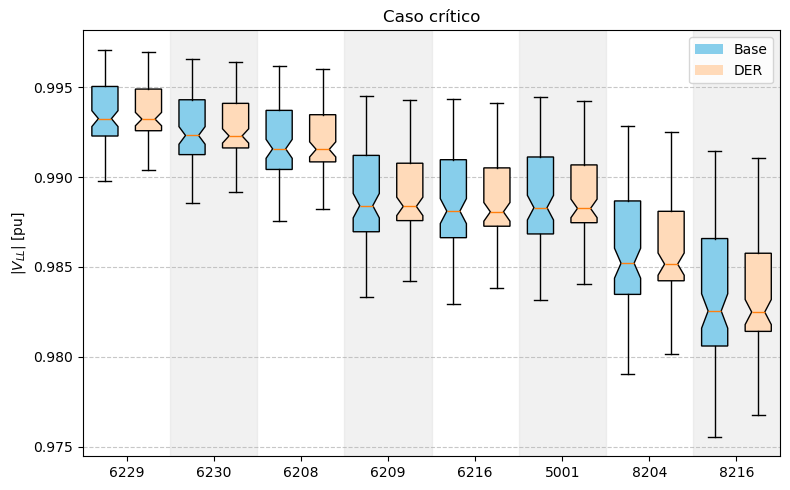

In [24]:
from matplotlib.patches import Patch

# Sample placeholder
# groups_data = [base1, der1, base2, der2]
# elements_id = ["LINE1", "LINE2"]

fig, ax = ht.plt.subplots(figsize=(8, 5))

# Shade background **per element group**
# Each element occupies two x positions: [1, 2] for LINE1, [3, 4] for LINE2
element_groups = [
    (i, i+1) for i in range(1, len(groups_data) + 1, 2)
]

# Color each box
colors = ['skyblue', 'peachpuff']  # lightgreen

# Shade only for even-indexed elements (starting from index 0)
for i, (start, end) in enumerate(element_groups):
    colors += colors
    if i % 2 == 1:  # i == 1 for LINE2
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            color='lightgrey',
            alpha=0.3,
            zorder=0
        )

# Draw boxplot
box = ax.boxplot(
    groups_data,
    patch_artist=True,
    widths=0.6,
    notch=True,
    showfliers=True,
)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis ticks centered for each element
span = [1.5]
for i in range(1, len(elements_id)):
    span.append(span[-1]+2)   # Space of two between devices

ax.set_xticks(span)
ax.set_xticklabels(elements_id)  # e.g., ["LINE1", "LINE2"]

# Add legend
legend_elements = [
    Patch(facecolor='skyblue', label='Base'),
    Patch(facecolor='peachpuff', label='DER'),
]
ax.legend(handles=legend_elements, loc='upper right')

# Axis labels and title
ax.set_ylabel(r"|$V_{LL}$| [pu]")
ax.set_title('Caso crítico')

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Layout
ht.plt.tight_layout()
# ht.plt.savefig("fig4.png", dpi=350)
ht.plt.show()


Es común que, ante la falta de carga durante períodos nocturnos, la tensión tienda a elevarse, y que en horario diurno —cuando aumenta la demanda— más bien disminuya. Con *SAEB* integrado, en cambio, ya se había advertido una suerte de regulación de tensión. En la próxima figura [] se contempla este comportamiento en una línea arbitraria: se observa, para el caso crítico, un perfil de tensión más uniforme, gracias tanto a la demanda nocturna como a la generación distribuida a la luz del día, aguas abajo del SAEB.

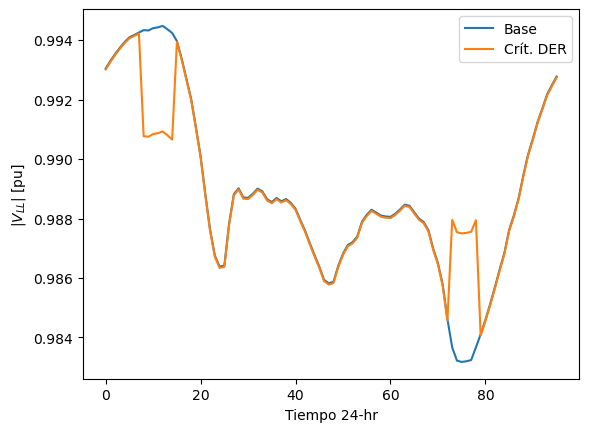

In [25]:
ht.plt.plot(groups_data[10], label="Base")
ht.plt.plot(groups_data[11], label="Crít. DER")
ht.plt.legend()
ht.plt.ylabel(r"|$V_{LL}$| [pu]")
ht.plt.xlabel("Tiempo 24-hr")
# ht.plt.savefig("fig5.png", dpi=350)
ht.plt.show()


Entre tanto, la parametrización económica del SAEB, cuya descarga no ocurre en el pico de tensión absoluto, por la figura [] desvela que estos beneficios menguan, si bien el primer interruptor visto por la subestación marca una diferencia de 54.54 [μV] y el más profundo de 99.44 [μV] a la par de la tendencia media de la situación base, resulta que la dispersión de los perfiles, a modo grueso reflejado por el tamaño de las cajas, es mayor con respecto al crítico, dando indicios de una tensión menos estable y así se reconoce en la figura [].

Aquella “potencia faltante”, mencionada al final de la sección de integración *DER* al sistema, en el caso económico, indica que parte de la energía gestionada por la batería no se refleja en la generación neta medida en la subestación, lo cual sugiere mayores pérdidas *locales* bajo esta configuración, si no fuera porque arrancó con un estado de carga generoso que hizo trasegar menos potencia desde la fuente la eficiencia de éste escenario se logró equiparar a la crítica, pero da luces, en cualquier caso, de que entre regular un filo de tensión global y uno local és más factible atacar el primero, consistente con el hecho de que las pérdidas son proporcionales al cuadrado de la tensión.


mean delta head:  -54.53514677355997
mean delta tail:  -99.43855548044667


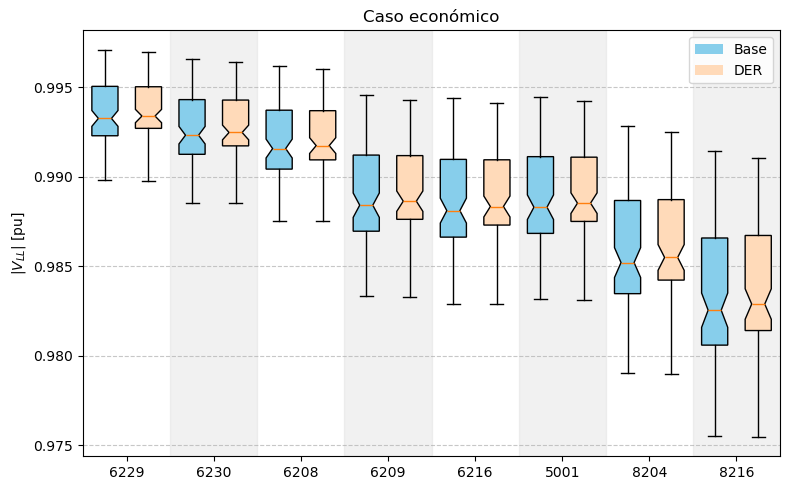

In [26]:
base_voltages = []
der_voltages = []
elements_id = []
for n, data in enumerate([base_vi_data, eco_vi_data]):
    for monitor_id, vals in data.items():
        if "battery" in monitor_id:
            continue
        obj_id = monitor_id.split("_")[-2]
        if obj_id not in elements_id:
            elements_id.append(obj_id)
        _, vi = vals.shape
        volt_mag_cols = range(2, vi//2 + 1, 2)
        avg_volt_mag = ht.np.sum(vals[:, volt_mag_cols], axis=1) / len(volt_mag_cols)
        volt_mag_pu = avg_volt_mag * 3**0.5 / 34.5e3
        if n == 0:
            base_voltages.append(volt_mag_pu)
        elif n == 1:
            der_voltages.append(volt_mag_pu)

# Alternate (Base1, DER1), (Base2, DER2) ...
groups_data = [] # Combine into a list for plotting
for base_v, der_v in zip(base_voltages, der_voltages):
    groups_data.append(base_v)
    groups_data.append(der_v)

delta_head = groups_data[0] - groups_data[1]
delta_tail = groups_data[-2] - groups_data[-1]

print("mean delta head: ", ht.np.mean(delta_head) * 1e6)
print("mean delta tail: ", ht.np.mean(delta_tail) * 1e6)

from matplotlib.patches import Patch

# Sample placeholder
# groups_data = [base1, der1, base2, der2]
# elements_id = ["LINE1", "LINE2"]

fig, ax = ht.plt.subplots(figsize=(8, 5))

# Shade background **per element group**
# Each element occupies two x positions: [1, 2] for LINE1, [3, 4] for LINE2
element_groups = [
    (i, i+1) for i in range(1, len(groups_data) + 1, 2)
]

# Color each box
colors = ['skyblue', 'peachpuff']  # lightgreen

# Shade only for even-indexed elements (starting from index 0)
for i, (start, end) in enumerate(element_groups):
    colors += colors
    if i % 2 == 1:  # i == 1 for LINE2
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            color='lightgrey',
            alpha=0.3,
            zorder=0
        )

# Draw boxplot
box = ax.boxplot(
    groups_data,
    patch_artist=True,
    widths=0.6,
    notch=True,
    showfliers=True,
)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis ticks centered for each element
span = [1.5]
for i in range(1, len(elements_id)):
    span.append(span[-1]+2)   # Space of two between devices

ax.set_xticks(span)
ax.set_xticklabels(elements_id)  # e.g., ["LINE1", "LINE2"]

# Add legend
legend_elements = [
    Patch(facecolor='skyblue', label='Base'),
    Patch(facecolor='peachpuff', label='DER'),
]
ax.legend(handles=legend_elements, loc='upper right')

# Axis labels and title
ax.set_ylabel(r"|$V_{LL}$| [pu]")
ax.set_title('Caso económico')

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Layout
ht.plt.tight_layout()
# ht.plt.savefig("fig6.png", dpi=350)
ht.plt.show()


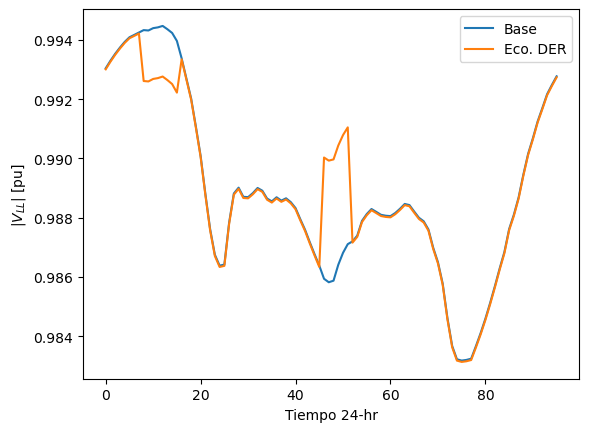

In [27]:
ht.plt.plot(groups_data[10], label="Base")
ht.plt.plot(groups_data[11], label="Eco. DER")
ht.plt.legend()
ht.plt.ylabel(r"|$V_{LL}$| [pu]")
ht.plt.xlabel("Tiempo 24-hr")
# ht.plt.savefig("fig7.png", dpi=350)
ht.plt.show()


Este comportamiento se puede comprender mejor a la luz del concepto de **Carga a la Impedancia Característica de la Línea** o *Surge Impedance Loading* (SIL), que representa una condición de carga en la que no se requiere intercambio de potencia reactiva entre la línea y la red, manteniéndose así una tensión más estable a lo largo de la línea. Cuando una línea opera **por encima del SIL** —como suele ocurrir durante la noche, con baja demanda— la línea entrega potencia reactiva; cuando opera **por debajo del SIL**, la línea la absorbe. Ambas condiciones pueden generar variaciones indeseadas de tensión y, eventualmente, ineficiencias operativas.

Al incorporar un SAEB aguas abajo, con despacho coordinado, se mitigan estos efectos. Por un lado, el sistema reduce la absorción de reactivo en las horas de alta carga, y por otro, atenúa la sobrecompensación durante la noche, promoviendo una operación más cercana al SIL. Esta *autorregulación distribuida* suaviza los perfiles de tensión en el tiempo y en el espacio, como lo evidencian los boxplots menos dispersos, y reduce tanto los picos como los valles de tensión en la red.

En términos energéticos, esto se traduce en una **mejora de la eficiencia del sistema**. Al reducir el flujo de potencia reactiva innecesaria, disminuyen también las pérdidas activas asociadas al transporte de corriente, particularmente durante picos de carga. Además, una tensión más estable reduce el estrés operativo sobre equipos sensibles —como transformadores o inversores— prolongando su vida útil y disminuyendo la necesidad de sobredimensionamiento.

En suma, el efecto combinado de:

* menores pérdidas técnicas (activas y térmicas),
* menor generación de reactivo desde la subestación,
* perfiles de tensión más uniformes,
* y operación más cercana al SIL,

constituye una evidencia del valor técnico que tecnologías como el SAEB pueden aportar al sistema eléctrico, especialmente en redes desbalanceadas con arquitectura radial.

## Estudio de fallas <a class="anchor" id="fourth-section"></a>

Se consideran los tipos de fallas:

* Falla trifásica de línea a línea a tierra (**$LLLG$**): Las tres fases (nodos 1, 2 y 3) están conectadas a tierra (nodo 0). Este es el tipo de falla más grave, ya que crea un cortocircuito entre las tres fases y tierra simultáneamente. Aunque en los próximos resultados parezca menor en magnitud los cierto es que sólo se reportan las corrientes de cortocircuito *por fase*, luego al tratarse de una falla balanceada la potencia que impone en realidad es tres veces más.
* Falla de Línea a Tierra (**$LG$** o SLG): Este es el tipo de falla más común en los sistemas eléctricos, representando una sola fase (fase A, nodo 1) que hace contacto con tierra. Representa entre el 70 % y el 80 % de todas las fallas en los sistemas de distribución.
* Falla Doble Línea-Tierra Tipo A (**$LLG_a$**): Representa una falla en la que dos fases (A y B, representadas como nodos 1 y 2) están conectadas entre sí y a tierra.
* Falla Doble Línea-Tierra Tipo B (**$LLG_b$**): Representa una falla en la que dos fases (fases A y B, nodos 1 y 2) están conectadas simultáneamente a tierra, creando rutas paralelas (separadas) a tierra a través de ambas fases.
* Falla Línea a Línea (**$LL$**): Representa una falla entre dos fases (fases A y B, nodos 1 y 2) sin conexión a tierra. Se implementa como un objeto de falla monofásica conectado entre dos fases diferentes. No implica referencia a tierra, lo que la diferencia de las fallas LLG.

Para el análisis de cortocircuito se asumirá la peor circunstancia según su escenario, es decir, el instante en que toda generación distribuida inyecta a la red su potencia nominal. El caso crítico y económico comparten la misma tasa de descarga de 5 [MW], por tanto el análisis aplica para ambos esquemas.

Las figuras a continuación alumbran corrientes de falla por cortocircuito contra la distancia [km], a partir de la subestación hasta la barra más alejada geométricamente, atravesadas por su respectiva regresión lineal para una comparación más estricta entre escenarios.

In [28]:
_ = base_ckt.fault_network()
_ = tec_ckt.fault_network()
# _ = eco_ckt.fault_network()

In [29]:
base_faults, base_buses = base_ckt.get_fault_currents()
tec_faults, tec_buses = tec_ckt.get_fault_currents()
# eco_faults, eco_buses = eco_ckt.get_fault_currents()


In [30]:
def linear_eq(
        x_vect: ht.np.ndarray,
        y_vect: ht.np.ndarray
) -> float:
    """Return ``m`` and ``b`` linear parameters.

    Compute slope :math:`m` and interception :math:`b`
    of short circuit current against distance.
    """
    # Calculate the mean of x and y
    x_mean = ht.np.mean(x_vect)
    y_mean = ht.np.mean(y_vect)

    # Calculate the slope (m)
    numerator = ht.np.sum((x_vect - x_mean) * (y_vect - y_mean))
    denominator = ht.np.sum((x_vect - x_mean)**2)
    m = numerator / denominator
    b = y_mean - m*x_mean
    return m, b


In [31]:
mv_buses_id = base_ckt.mv_buses_id
lv_buses_id = base_ckt.lv_buses_id
mv_indices: list[list] = []
lv_indices: list[list] = []

for faulted in base_buses:
    mv_i = []
    lv_i = []
    for i, bus in enumerate(faulted):
        if bus in mv_buses_id:
            mv_i.append(i)
        elif bus in lv_buses_id:
            lv_i.append(i)
        else:
            pass
    mv_indices.append(mv_i)
    lv_indices.append(lv_i)


### Fallas en media tensión <a class="anchor" id="mv-faults"></a>

Se aprecia de la figura [] que para cualquier falla la regresión lineal del caso DER $l_{\text{DER}}$ es prácticamente paralela a la base $l_{\text{base}}$, luego

$$
l_{\text{DER}} = l_{\text{base}} + \epsilon \quad ; \quad \epsilon > 0
$$

O sea simplemente hay un corrimiento vertical hacia arriba, esto sugiere que la presencia de DER introduce un incremento sistemático en la magnitud de las corrientes de falla a lo largo del circuito, sin alterar sustancialmente la tendencia espacial dictada por la impedancia de Thevenin.
Se nota también, al menos en zona de media tensión, que la tendencia es decreciente pues cuanto más alejado el punto de falla de la subestación, mayor será la impedancia de Thevenin vista desde la fuente. En consecuencia, la corriente de cortocircuito disminuye progresivamente con la distancia, como es típico en redes radiales.

Puntualmente el $\epsilon$ equivale a un aumento de 166.68 [A]. Si la corriente nominal por fase es

$$
|I|_{f} = \frac{P}{\sqrt{3} \cdot V_{LL} \cdot fp} = 83.67 \quad [A]
$$

O sea casi el doble de la corriente nominal, un aporte sustancial a la corriente de corto circuito aunque dentro del rango típico si de SAEB se trata.


>>>> LLLG
>>>> epsilon: 199.15584802875674
>>>> LG
>>>> epsilon: 128.687506170686
>>>> LLG
>>>> epsilon: 128.68630977723296
>>>> LLG
>>>> epsilon: 100.63167480340053
>>>> LL
>>>> epsilon: 166.6887715991752


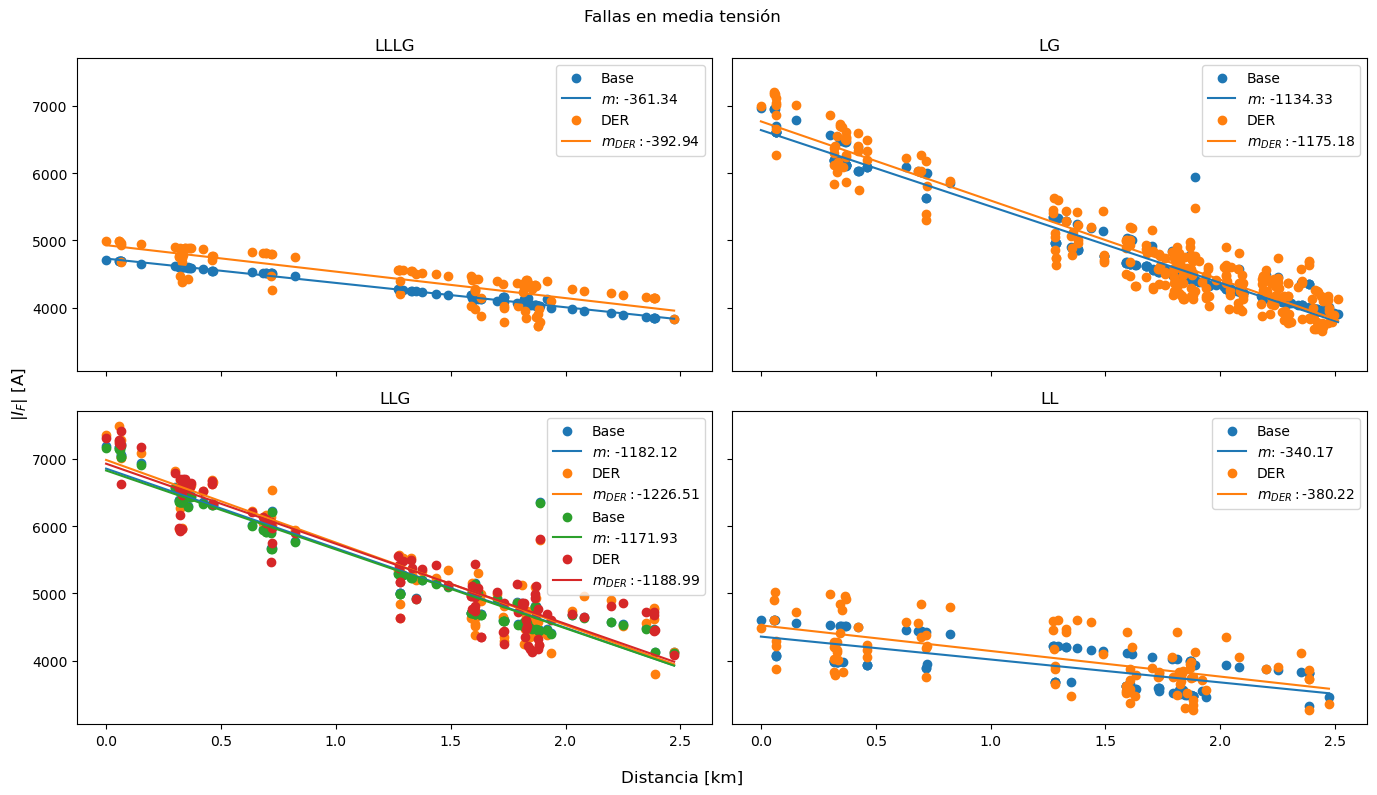

In [32]:
fault_types = ["LLLG", "LG", "LLG", "LLG", "LL"]

fig, axs = ht.plt.subplots(
    2, 2, sharex=True, sharey=True, figsize=(14, 8)
)
indx = {
    0: (0, 0),  # LLLG
    1: (0, 1),  # LG
    2: (1, 0),  # LLG a
    3: (1, 0),  # LLG b
    4: (1, 1)   # LL
}

for n, fault in enumerate(fault_types):
    # Base
    x = base_faults[n][mv_indices[n][:], 1]  # Distance [km]
    y = base_faults[n][mv_indices[n][:], 0]  # Current [A]
    m, b = linear_eq(x, y)
    axs[indx[n]].scatter(x, y, label="Base")
    axs[indx[n]].plot(x, m*x+b, label=r"$m$: "+f"{m:.2f}")
    axs[indx[n]].set_title(fault)
    axs[indx[n]].legend()
    # DER
    u = tec_faults[n][mv_indices[n][:], 1]  # Distance [km]
    v = tec_faults[n][mv_indices[n][:], 0]  # Current [A]
    p, q = linear_eq(u, v)
    print(f">>>> {fault}")
    print(f">>>> epsilon: {q - b}")
    axs[indx[n]].scatter(u, v, label="DER")
    axs[indx[n]].plot(u, p*u+q, label=r"$m_{DER}: $"+f"{p:.2f}")
    axs[indx[n]].set_title(fault)
    axs[indx[n]].legend()


fig.suptitle("Fallas en media tensión")
fig.supxlabel("Distancia [km]")
fig.supylabel(r"|$I_{F}$| [A]")
fig.tight_layout()
# ht.plt.savefig("fig8.png", dpi=300)
ht.plt.show()

### Fallas en baja tensión <a class="anchor" id="lv-faults"></a>

En el nivel de baja tensión, se observa una regresión lineal relativamente constante en torno a los **2000 A** para ambos escenarios (con y sin DER), lo cual indica una escasa variabilidad de las corrientes de falla a lo largo del circuito. Esta estabilidad se debe, en parte, a que la impedancia en baja tensión es predominantemente local y las trayectorias eléctricas son cortas, lo que atenúa el efecto de la distancia geométrica desde la subestación.

Además, se aprecia que la densidad de fallas —especialmente las no trifásicas— tiende a incrementarse en zonas alejadas de la subestación. Esta tendencia responde a la propia topología del sistema de distribución en baja tensión, donde se conectan numerosas derivaciones monofásicas y bifásicas orientadas a clientes residenciales.

Como es de esperarse, hay **pocas barras trifásicas en baja tensión**, usualmente asociadas a cargas comerciales o industriales. No obstante, resultan llamativos algunos **picos aislados** de corriente de falla que se apartan significativamente de la tendencia general, alcanzando valores tan altos como **12,581.56 A** para el caso de una falla $LLG_a$. Estos saltos atípicos se explican por la **presencia de generación distribuida conectada directamente en dichas barras**, incluso en el escenario base, lo cual aumenta significativamente la contribución a la corriente de cortocircuito.


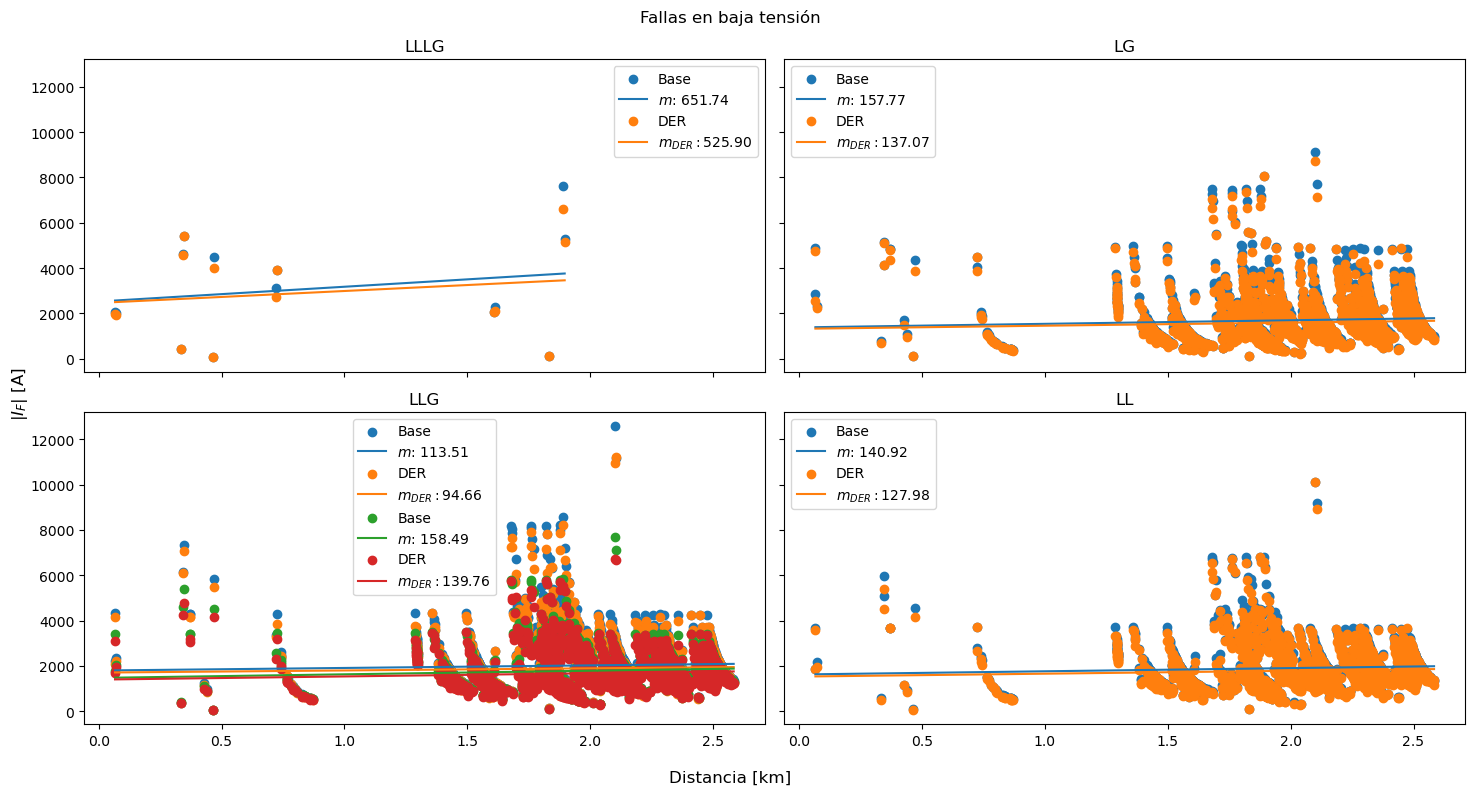

In [33]:
fig, axs = ht.plt.subplots(
    2, 2, sharex=True, sharey=True, figsize=(15, 8)
)
indx = {
    0: (0, 0),  # LLLG
    1: (0, 1),  # LG
    2: (1, 0),  # LLG a
    3: (1, 0),  # LLG b
    4: (1, 1)   # LL
}

for n, fault in enumerate(fault_types):
    # Base
    x = base_faults[n][lv_indices[n][:], 1]  # Distance [km]
    y = base_faults[n][lv_indices[n][:], 0]  # Current [A]
    m, b = linear_eq(x, y)
    axs[indx[n]].scatter(x, y, label="Base")
    axs[indx[n]].plot(x, m*x+b, label=r"$m$: "+f"{m:.2f}")
    axs[indx[n]].set_title(fault)
    axs[indx[n]].legend()
    # DER
    u = tec_faults[n][lv_indices[n][:], 1]  # Distance [km]
    v = tec_faults[n][lv_indices[n][:], 0]  # Current [A]
    p, q = linear_eq(u, v)
    axs[indx[n]].scatter(u, v, label="DER")
    axs[indx[n]].plot(u, p*u+q, label=r"$m_{DER}: $"+f"{p:.2f}")
    axs[indx[n]].set_title(fault)
    axs[indx[n]].legend()


fig.suptitle("Fallas en baja tensión")
fig.supxlabel("Distancia [km]")
fig.supylabel(r"|$I_{F}$| [A]")
fig.tight_layout()
# ht.plt.savefig("fig9.png", dpi=300)
ht.plt.show()


### Exploring *odd* fault currents

- Maximum fault current all across the circuit

In [ ]:
n_faults = len(base_faults)
max_indices = [
    ht.np.argmax(base_faults[n][:, 0])
    for n in range(n_faults)
]

for fault, i in enumerate(max_indices):
    print(f"BusID: {base_buses[fault][i]}")
    print(f"\tCurrent [A]: {base_faults[fault][i, 0]}")

## Curvas de tiempo para coordinación de protecciones <a class="anchor" id="protection-curves"></a>

## Conclusiones <a class="anchor" id="end"></a>


1. **Adecuada calibración del modelo eléctrico:** El modelo validado refleja fielmente el comportamiento de la red, con una diferencia menor al 3.5 % entre la demanda pico medida y simulada. Esta ligera sobredimensión refuerza la robustez del análisis, proporcionando márgenes de seguridad útiles para evaluar el impacto de nuevas tecnologías.

2. **Impacto del SAEB bajo distintas estrategias de operación:** Se analizaron dos modos de despacho (crítico y económico) de un Sistema de Almacenamiento de Energía con Batería (SAEB). En ambos casos, el dispositivo logra integrarse adecuadamente a la red, pero con efectos distintos sobre la eficiencia del sistema. El escenario crítico, al estar alineado con los picos de demanda, mostró un uso más eficiente de la energía, mientras que el económico evidenció mayores pérdidas locales, aunque con menor carga percibida por la subestación.

3. **Reducción de pérdidas activas:** En el escenario crítico, las pérdidas técnicas activas disminuyeron en 0.18 MW (25.32 MW frente a 25.50 MW del caso base), mientras que en el económico la reducción fue de 0.38 MW. No obstante, al comparar estas reducciones en relación con la energía generada, ambas estrategias presentan una eficiencia relativa idéntica del 1.70 % ya no 1.72% del caso base original, lo cual revela que el efecto neto en pérdidas está más vinculado a la reducción de carga que a la eficiencia del dispositivo en sí.

4. **Soporte reactivo y menor esfuerzo desde la subestación:** El SAEB, pese a operar con factor de potencia unitario, entregó netamente potencia reactiva a la red debido al comportamiento inductivo del inversor. Esto se tradujo en una reducción de entre 0.70 % y 1.41 % en la generación de VAr desde la subestación, dependiendo del modo de operación. Esta reducción mejora el ángulo de carga y favorece la estabilidad de la red.

5. **Uniformidad en perfiles de tensión:** El análisis estadístico mediante diagramas de caja evidenció perfiles de tensión más compactos y menos dispersos en presencia del SAEB, especialmente bajo el despacho crítico. Esto demuestra una mejor regulación de tensión a lo largo del circuito, reduciendo tanto caídas como sobrevoltajes. La operación más cercana al *Surge Impedance Loading* (SIL) sugiere una autorregulación reactiva distribuida que optimiza el desempeño eléctrico de la red.

6. **Estabilidad operacional y beneficios técnicos:** Una tensión más estable disminuye el estrés sobre equipos sensibles, prolonga la vida útil de los activos y reduce la necesidad de sobredimensionamiento. Esto se traduce en un sistema más confiable, resiliente y económicamente eficiente.

7. **Impacto manejable en corrientes de falla:** En media tensión, la integración del SAEB genera un aumento sistemático (≈167 A) en las corrientes de falla, pero sin modificar su tendencia decreciente con la distancia. En baja tensión, las corrientes se mantienen alrededor de 2000 A, aunque con algunos picos locales causados por generación distribuida ya existente. Esto destaca la necesidad de revisar y ajustar la coordinación de protecciones, sin que se comprometa la seguridad operativa.


---

## Referencias y Documentación <a class="anchor" id="references"></a>

[1] [DERify](https://github.com/MarioPeraltaA/DERify) <br>
[2] [OpenDSS Manual](https://opendss.epri.com/CircuitModelConcept.html) <br>
[3] [COM Interface](https://dss-extensions.org/index.html) <br>

---